**Problem 1b**

In [22]:
import numpy as np
import matplotlib.pyplot as plt

p = np.array([
    [0, 1, 0, 0, 0],
    [.25, 0, .75, 0, 0],
    [0, .5, 0, .5, 0],
    [0, 0, .75, 0, .25],
    [0, 0, 0, 1, 0]
])

q_0 = np.array([1, 0, 0, 0, 0])
q = np.zeros((61, 5))
q[0] = q_0

for n in range(60):
    q[n + 1] = q[n] @ p

print(f"q_50 = {np.round(q[50], 3)}")
print(f"q_51 = {np.round(q[51], 3)}")

run_avg = np.zeros(61)
n_values = range(61)
for n in range(61):
    run_avg[n] = np.mean(q[:n + 1, 2])

#moved plot down with 1c

q_50 = [0.125 0.    0.75  0.    0.125]
q_51 = [0.  0.5 0.  0.5 0. ]


**Problem 1c**

In [23]:
from math import comb

#I'm not hardcoding p this time
p = np.zeros((5, 5))
a = 0.3
b = 0.1

for k in range(5):
    if k < 4:
        p[k, k + 1] = a * (4 - k) / 4

    if k > 0:
        p[k, k - 1] = b * k /4

    p[k, k] = 1 - np.sum(p[k])

A = p.T - np.eye(5)
A[-1, :] = 1
r = np.zeros(5)
r[-1] = 1

pi = np.linalg.solve(A, r)

#check by computer as well:
theta = a / (a + b)

pi_bin = np.array([
    comb(4, k) * theta ** k * (1 - theta) ** (4 - k)
    for k in range(5)
])

difference = (pi_bin - pi).round(6)

print(f"Linear Solve: {pi.round(6)}")
print(f"Binomial: {pi_bin.round(6)}")
print(f"Difference: {difference}")


Linear Solve: [0.003906 0.046875 0.210937 0.421875 0.316406]
Binomial: [0.003906 0.046875 0.210938 0.421875 0.316406]
Difference: [-0.  0.  0.  0. -0.]


Smallest n: 134
Error at n: 9.349776263767318e-07
Eigenvalues: [0.6+0.j 0.7+0.j 0.8+0.j 0.9+0.j 1. +0.j]
Second largest modulus: 0.9


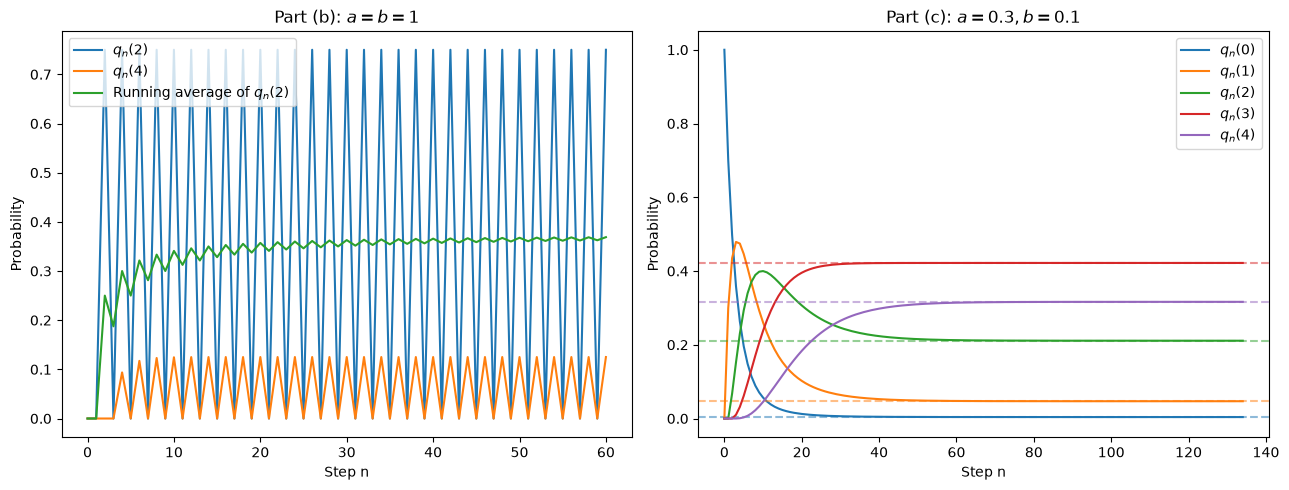

In [29]:
#smallest n
q_current = np.array([1., 0, 0, 0, 0])
history = [q_current.copy()]
n = 0

while np.max(np.abs(q_current - pi)) >= 1e-6:
    q_current = q_current @ p
    history.append(q_current.copy())
    n += 1

q_c = np.array(history)

print(f"Smallest n: {n}")
print(f"Error at n: {np.max(np.abs(q_current - pi))}")

eigenval = np.linalg.eigvals(p)
moduli = np.sort(np.abs(eigenval))[:: -1]

print(f"Eigenvalues: {np.round(eigenval, 6)}")
print(f"Second largest modulus: {round(moduli[1], 6)}")

#plot!
fig, axes = plt.subplots(1, 2, figsize = (13, 5))

#plot1
ax = axes[0]
ax.plot(n_values, q[:, 2], label = r"$q_n(2)$")
ax.plot(n_values, q[:, 4], label = r"$q_n(4)$")
ax.plot(n_values, run_avg, label = r"Running average of $q_n(2)$")
ax.set_title(r"Part (b): $a = b = 1$")

#plot2
ax = axes[1]
n_c = np.arange(len(q_c))

for k in range(5):
    line, = ax.plot(n_c, q_c[:, k], label = fr"$q_n({k})$")
    ax.axhline(
        pi[k], color = line.get_color(), linestyle = "--", alpha = 0.5
    )

ax.set_title(r"Part (c): $a = 0.3, b = 0.1$")


for ax in axes:
    ax.set_xlabel("Step n")
    ax.set_ylabel("Probability")
    ax.legend()

fig.tight_layout()
fig.savefig("HW5_P1c.png", dpi = 300, bbox_inches = "tight")
plt.show()